# Text Analysis Case Study: News Headlines

### Import Required Libraries

In [3]:
# Import libraries
import pandas as pd
import re
import nltk
import spacy
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from gensim import corpora, models
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import uuid

# Download required NLTK data
nltk.download('stopwords')
nltk.download('punkt')

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# Initialize VADER sentiment analyzer
vader_analyzer = SentimentIntensityAnalyzer()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Load and Explore Dataset

In [5]:
# Load dataset
df = pd.read_csv('news_text_analysis.csv')

# Display dataset info and samples
print("Dataset Info:")
display(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 637 entries, 0 to 636
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   S.No          637 non-null    int64 
 1   Headline      637 non-null    object
 2   Source        637 non-null    object
 3   Link          637 non-null    object
 4   Category      637 non-null    object
 5   Timestamp     637 non-null    object
 6   Cleaned_Text  637 non-null    object
 7   Sentiment     637 non-null    object
dtypes: int64(1), object(7)
memory usage: 39.9+ KB


None

In [6]:
print("\nFirst 5 Rows:")
display(df.head())




First 5 Rows:


,S.No,Headline,Source,Link,Category,Timestamp,Cleaned_Text,Sentiment
0,1,'If Operation Sindoor was ongoing ... ': Congr...,TOI,https://timesofindia.indiatimes.com/india/if-o...,India,2025-09-29T10:30:49+05:30,operation sindoor ongoing congress slams modis...,Positive
1,2,Karur stampede: Rahul Gandhi dials Vijay; offe...,TOI,https://timesofindia.indiatimes.com/india/karu...,India,2025-09-29T10:24:38+05:30,karur stampede rahul gandhi dials vijay offers...,Negative
2,3,HIV jab for 115 nations rests on Indian regula...,TOI,https://timesofindia.indiatimes.com/india/hiv-...,India,2025-09-29T05:17:52+05:30,hiv jab nations rests indian regulators,Neutral
3,4,Illegal betting: ED may attach assets of celebs,TOI,https://timesofindia.indiatimes.com/india/ille...,India,2025-09-29T04:19:59+05:30,illegal betting may attach assets celebs,Negative
4,5,"Cancer cases in India up by 26%, deaths 21% si...",TOI,https://timesofindia.indiatimes.com/india/canc...,India,2025-09-29T04:12:26+05:30,cancer cases india deaths since,Neutral


In [7]:
print("\nSentiment Distribution (Original):")
display(df['Sentiment'].value_counts())


Sentiment Distribution (Original):


Sentiment
Neutral     410
Positive    129
Negative     98
Name: count, dtype: int64

### Text Cleaning and Preprocessing

#### We’ll clean text by:

* Lowercasing

* Removing URLs and punctuation

* Lemmatizing words using spaCy

* Removing stopwords and domain-specific words (like “India”, “say”)

In [8]:
# Define enhanced stopword list
stop_words = set(stopwords.words('english')).union({'india', 'indian', 'say', 'says'})

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-z\s]', '', text)        # Remove non-letters
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if token.text not in stop_words and len(token.text) > 2]
    cleaned_text = ' '.join(tokens)
    return cleaned_text if cleaned_text.strip() else 'no_content'

# Apply cleaning
df['Cleaned_Text'] = df['Headline'].apply(clean_text)

# Display cleaned examples
df[['Headline', 'Cleaned_Text']].head()


,Headline,Cleaned_Text
0,'If Operation Sindoor was ongoing ... ': Congr...,operation sindoor ongoing congress slam modis ...
1,Karur stampede: Rahul Gandhi dials Vijay; offe...,karur stampede rahul gandhi dial vijay offer c...
2,HIV jab for 115 nations rests on Indian regula...,hiv jab nation rest regulator
3,Illegal betting: ED may attach assets of celebs,illegal bet may attach asset celebs
4,"Cancer cases in India up by 26%, deaths 21% si...",cancer case death since


* words like “running”, “ran” become “run”, and unnecessary symbols are removed.

### Sentiment Analysis (VADER)

* We use the VADER lexicon-based sentiment analyzer, which is effective for short, informal text like headlines.

In [9]:
def get_vader_sentiment(text):
    scores = vader_analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound > 0.05:
        return 'Positive'
    elif compound < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply VADER sentiment
df['VADER_Sentiment'] = df['Cleaned_Text'].apply(get_vader_sentiment)

# Compare results
print("\nVADER Sentiment Distribution:")
display(df['VADER_Sentiment'].value_counts())

print("\nComparison of Original vs VADER:")
display(pd.crosstab(df['Sentiment'], df['VADER_Sentiment']))



VADER Sentiment Distribution:


VADER_Sentiment
Neutral     265
Negative    205
Positive    167
Name: count, dtype: int64


Comparison of Original vs VADER:


VADER_Sentiment,Negative,Neutral,Positive
Sentiment,,,
Negative,58,21,19
Neutral,120,209,81
Positive,27,35,67


### Topic Modeling with LDA (Latent Dirichlet Allocation)

* We’ll discover underlying themes/topics in the headlines.

In [10]:
# Prepare text corpus
texts = [t.split() for t in df['Cleaned_Text'] if t != 'no_content']
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Compute coherence to find optimal topic count
def compute_coherence_values(dictionary, corpus, texts, start, limit, step):
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model = models.LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=15, random_state=42)
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())
    return model_list, coherence_values

model_list, coherence_values = compute_coherence_values(dictionary, corpus, texts, start=2, limit=6, step=1)

# Choose best model
optimal_topics = coherence_values.index(max(coherence_values)) + 2
lda_model = model_list[coherence_values.index(max(coherence_values))]

print(f"Optimal Number of Topics: {optimal_topics}")
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}")


Optimal Number of Topics: 2
Topic 0: 0.011*"trump" + 0.007*"new" + 0.005*"tiktok" + 0.005*"deal" + 0.003*"watch" + 0.003*"trade" + 0.003*"government" + 0.003*"minister" + 0.003*"year" + 0.003*"claim"
Topic 1: 0.006*"asia" + 0.006*"cup" + 0.006*"tech" + 0.004*"life" + 0.004*"crore" + 0.004*"report" + 0.003*"use" + 0.003*"iran" + 0.003*"rise" + 0.003*"court"


#### 🔹 Overview
The model identified **2 main topics** from the dataset using **Latent Dirichlet Allocation (LDA)**.  
Each topic is represented by a group of keywords that frequently occur together, revealing underlying patterns or themes in the news headlines.

---

#### 🔢 Optimal Number of Topics: **2**

The optimal number of topics was determined using the **Coherence Score**, which measures how interpretable the topics are based on word co-occurrence patterns.  
A higher coherence score generally means more meaningful and consistent topics.  
In this case, **2 topics** gave the highest coherence, meaning the dataset naturally clusters into two dominant themes.

---

#### 🧩 Topic 0
**Top Words:**  
0.011*"trump" + 0.007*"new" + 0.005*"tiktok" + 0.005*"deal" + 0.003*"watch" + 0.003*"trade" + 0.003*"government" + 0.003*"minister" + 0.003*"year" + 0.003*"claim"

**Interpretation:**  
This topic includes keywords like **"trump"**, **"tiktok"**, **"deal"**, **"trade"**, and **"government"**, which point to **international politics, policy decisions, and governance**.  
It likely represents articles related to **global or political news**, such as diplomatic relations, government actions, or economic trade issues.

---

#### 🧩 Topic 1
**Top Words:**  
0.006*"asia" + 0.006*"cup" + 0.006*"tech" + 0.004*"life" + 0.004*"crore" + 0.004*"report" + 0.003*"use" + 0.003*"iran" + 0.003*"rise" + 0.003*"court"

**Interpretation:**  
This topic contains terms like **"asia"**, **"cup"**, **"tech"**, **"report"**, **"rise"**, and **"court"**, suggesting a mix of **sports (Asia Cup)**, **technology**, and **current affairs**.  
It may correspond to **domestic or event-based news** such as sports updates, tech trends, or judicial/economic reports.

---

#### 📊 Summary Table

| Topic | Dominant Theme | Representative Keywords |
|:------|:----------------|:-------------------------|
| **0** | Global Politics / Governance | trump, tiktok, deal, trade, government |
| **1** | Sports / Tech / Current Affairs | asia, cup, tech, report, court |

---

#### 🧾 Key Takeaway
- **Topic 0** reflects **political and international news**.  
- **Topic 1** represents **sports, technology, and general current affairs**.  
Together, they capture the **two major types of content** present in your news dataset.


### 📊 Visualizations

1️⃣ Sentiment Distribution (VADER)

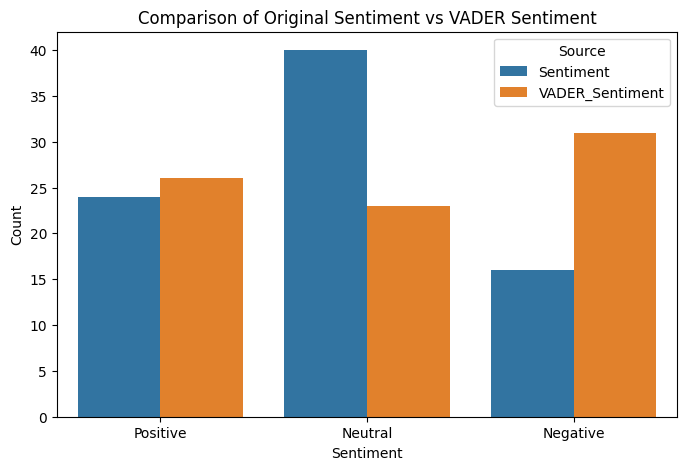

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data in long format for double bar plot
df_melt = df.melt(id_vars=['S.No'], value_vars=['Sentiment', 'VADER_Sentiment'],
                  var_name='Source', value_name='Sentiment_Label')

# Plot
plt.figure(figsize=(8,5))
sns.countplot(data=df_melt, x='Sentiment_Label', hue='Source', 
              order=['Positive', 'Neutral', 'Negative'], palette=['#1f77b4', '#ff7f0e'])
plt.title('Comparison of Original Sentiment vs VADER Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.legend(title='Source')
plt.show()


2️⃣ Word Cloud of All Headlines

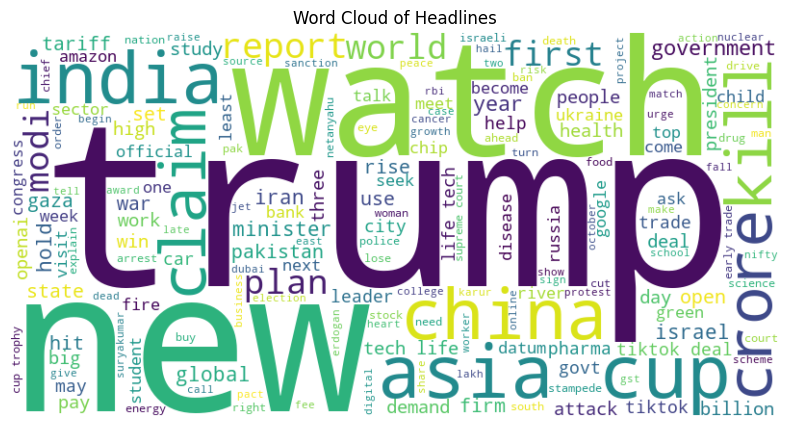

In [13]:
all_text = ' '.join(df['Cleaned_Text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', min_font_size=10).generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Headlines')
plt.show()


3️⃣ Top Words per Topic

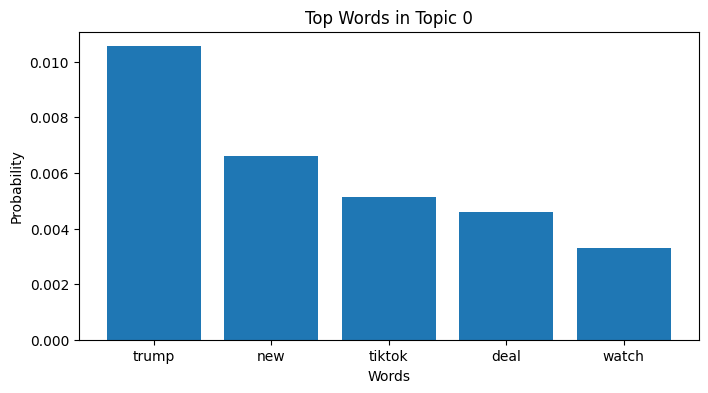

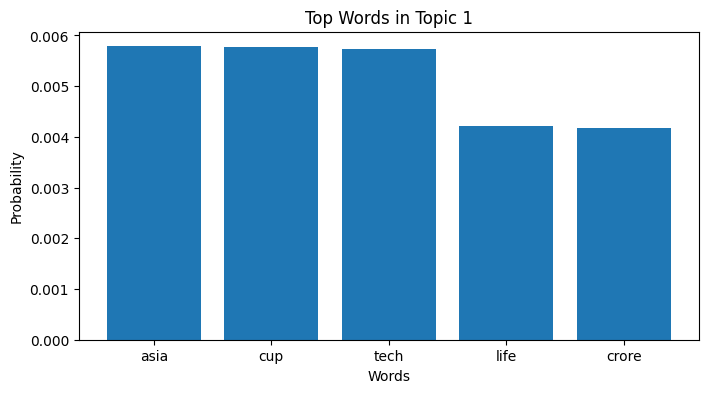

In [14]:
for idx, topic in lda_model.show_topics(formatted=False, num_words=5):
    words = [word for word, _ in topic]
    probs = [prob for _, prob in topic]
    plt.figure(figsize=(8,4))
    plt.bar(words, probs)
    plt.title(f'Top Words in Topic {idx}')
    plt.xlabel('Words')
    plt.ylabel('Probability')
    plt.show()


4️⃣ Sentiment Over Time

C:\Users\HP\AppData\Local\Temp\ipykernel_18572\1198257343.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce', infer_datetime_format=True)


<Figure size 1200x600 with 0 Axes>

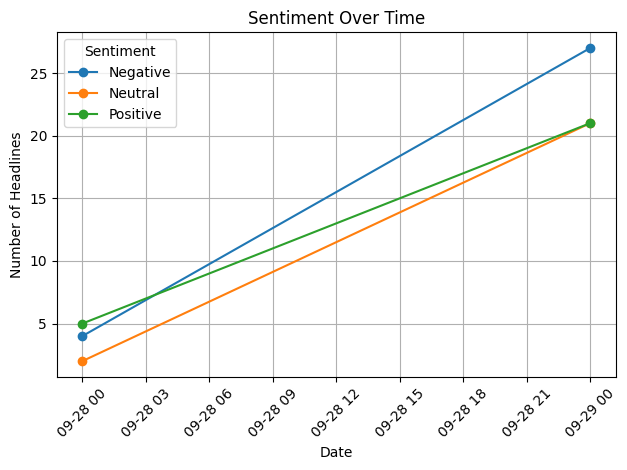

In [23]:
# Force mixed datetime parsing safely
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce', infer_datetime_format=True)

# Drop rows where Timestamp couldn't be parsed (optional, but prevents errors)
df = df.dropna(subset=['Timestamp'])

# Extract the date portion
df['Date'] = df['Timestamp'].dt.date

# Group by Date and VADER Sentiment
sentiment_over_time = df.groupby(['Date', 'VADER_Sentiment']).size().unstack(fill_value=0)

# Plot Sentiment Trends Over Time
plt.figure(figsize=(12, 6))
sentiment_over_time.plot(kind='line', marker='o')
plt.title('Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Headlines')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


🤖 Predictive Model (TF-IDF + Logistic Regression)

In [17]:
# Prepare data
X = df['Cleaned_Text']
y = df['VADER_Sentiment']

# Convert text to TF-IDF features
vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = vectorizer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Train logistic regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.45      0.56        47
     Neutral       0.51      0.84      0.64        50
    Positive       0.78      0.45      0.57        31

    accuracy                           0.60       128
   macro avg       0.68      0.58      0.59       128
weighted avg       0.66      0.60      0.59       128

